# Scary Stochastics, Week 1: Markov Chains
## Notebook 2 of 3 — Calibrating the Transition Matrix

This notebook is self-contained (it regenerates the same synthetic harvest with the same random seed as Notebook 1), then estimates a Markov chain transition matrix from the 10-year sequence of harvest categories.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Harvest / Halloween color palette
HARVEST = {
    "poor":    "#3B2145",  # deep purple  - a rough year
    "average": "#B5451B",  # burnt orange/rust
    "good":    "#E8741C",  # pumpkin orange
    "bumper":  "#D9A404",  # golden mustard - the best years
    "black":   "#1B1B1B",
    "cream":   "#FBF3E1",
}

CATS = ["Poor", "Average", "Good", "Bumper"]
CAT_COLORS = [HARVEST["poor"], HARVEST["average"], HARVEST["good"], HARVEST["bumper"]]

plt.rcParams.update({
    "figure.facecolor": HARVEST["cream"],
    "axes.facecolor": HARVEST["cream"],
    "axes.edgecolor": HARVEST["black"],
    "text.color": HARVEST["black"],
    "axes.labelcolor": HARVEST["black"],
    "xtick.color": HARVEST["black"],
    "ytick.color": HARVEST["black"],
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

### Regenerate the same 10-year harvest

In [2]:
# Synthetic 10-year pumpkin harvest (tons/acre)
years = np.arange(2016, 2026)
base_yield = 15
yields_ = base_yield + np.random.normal(0, 4, size=10)
yields_ = np.clip(yields_, 3, None).round(1)

harvest_df = pd.DataFrame({"Year": years, "Yield_tons_per_acre": yields_})
harvest_df["Category"] = pd.qcut(harvest_df["Yield_tons_per_acre"], q=4, labels=CATS)
harvest_df

,Year,Yield_tons_per_acre,Category
0,2016,17.0,Average
1,2017,14.4,Average
2,2018,17.6,Good
3,2019,21.1,Bumper
4,2020,14.1,Poor
5,2021,14.1,Poor
6,2022,21.3,Bumper
7,2023,18.1,Bumper
8,2024,13.1,Poor
9,2025,17.2,Good


### Count observed transitions

Ten years of data means only **nine** year-to-year transitions — small enough that some state pairs may never appear.

In [3]:
sequence = harvest_df["Category"].tolist()

raw_counts = pd.DataFrame(0, index=CATS, columns=CATS)
for a, b in zip(sequence[:-1], sequence[1:]):
    raw_counts.loc[a, b] += 1

raw_counts

,Poor,Average,Good,Bumper
Poor,1,0,1,1
Average,0,1,1,0
Good,0,0,0,1
Bumper,2,0,0,1


### Smooth and normalize

We add Laplace (+1) smoothing before row-normalizing so no transition is estimated as impossible just because we didn't happen to observe it in nine data points. This is the "calibrate" half of the calibrate-then-simulate approach — the matrix below is a reasonable estimate, not a certainty, given the sample size.

In [4]:
smoothed = raw_counts + 1
transition_matrix = smoothed.div(smoothed.sum(axis=1), axis=0)
transition_matrix

,Poor,Average,Good,Bumper
Poor,0.285714,0.142857,0.285714,0.285714
Average,0.166667,0.333333,0.333333,0.166667
Good,0.200000,0.200000,0.200000,0.400000
Bumper,0.428571,0.142857,0.142857,0.285714


### Visual 3 — Transition matrix heatmap

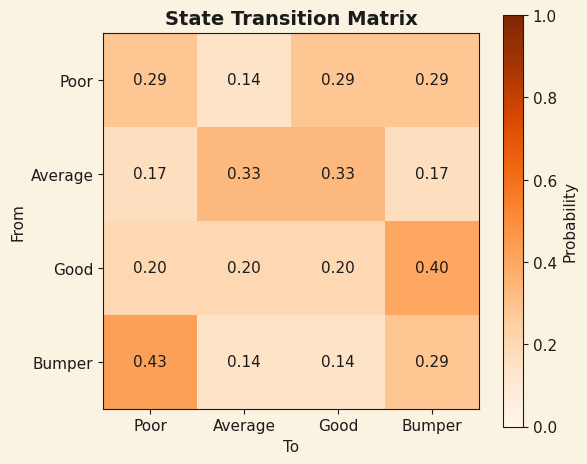

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(transition_matrix.values, cmap="Oranges", vmin=0, vmax=1)
ax.set_xticks(range(4)); ax.set_xticklabels(CATS)
ax.set_yticks(range(4)); ax.set_yticklabels(CATS)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_title("State Transition Matrix")
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{transition_matrix.values[i, j]:.2f}",
                ha="center", va="center", color=HARVEST["black"])
plt.colorbar(im, label="Probability")
plt.tight_layout()
plt.savefig("03_transition_matrix.png", dpi=150, facecolor=HARVEST["cream"])
plt.show()

### Visual 4 — Chain diagram

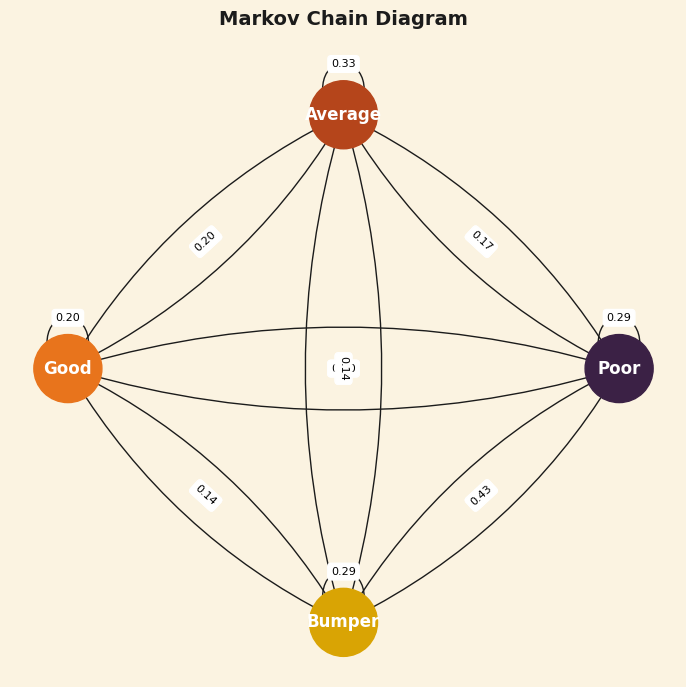

In [6]:
import networkx as nx

G = nx.DiGraph()
for a in CATS:
    for b in CATS:
        p = transition_matrix.loc[a, b]
        if p > 0.05:
            G.add_edge(a, b, weight=p)

pos = nx.circular_layout(G)
fig, ax = plt.subplots(figsize=(7, 7))
nx.draw_networkx_nodes(G, pos, nodelist=CATS, node_color=CAT_COLORS, node_size=2400, ax=ax)
nx.draw_networkx_labels(G, pos, font_color="white", font_weight="bold", ax=ax)
nx.draw_networkx_edges(G, pos, connectionstyle="arc3,rad=0.15",
                        arrowsize=15, edge_color=HARVEST["black"], ax=ax)
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, ax=ax)
ax.set_title("Markov Chain Diagram")
ax.axis("off")
plt.tight_layout()
plt.savefig("04_markov_diagram.png", dpi=150, facecolor=HARVEST["cream"])
plt.show()

### Save for Notebook 3

In [7]:
transition_matrix.to_csv("transition_matrix.csv")